In [1]:
import os
import time
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import MLP, LatentConditionedResidualDynamics
from lotf.objects import Quadrotor

%matplotlib inline

# Training Latent-Conditioned Residual Dynamics

## 1. Seed

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## 2. Define Simulation Dynamics Config

In [16]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": False,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [17]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,  # equation (2): v_dot += w
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

====== eval_env info ======
action_dim: 4
obs_dim: 27


## 4. Load the Trained Policy

In [18]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
loaded_train_state = TrainState.create(apply_fn=base_policy_net.apply, params=base_policy_params, tx=optax.adam(1e-3))

# define policy function
def policy_trained(obs, key):
    return loaded_train_state.apply_fn(loaded_train_state.params, obs)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 5. Collect the Transition Dataset

In [19]:
# The paper stores raw (s_t, a_t, s_{t+1}) transitions. The fixed latent and
# hidden acceleration selected at reset are retained with every transition.
num_rollouts = 256
key, key_rollouts = jax.random.split(key)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, policy_trained, dummy_residual_params
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
next_states = state_vectors(
    quad_states.p[:, 1:], quad_states.R[:, 1:], quad_states.v[:, 1:]
)

# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
latent_z = env_states.latent_z[:, :-1, :]
hidden_acceleration = env_states.hidden_acceleration[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

dataset = {
    "state": states[valid_transition],
    "action": actions[valid_transition],
    "state_action": state_actions[valid_transition],
    "next_state": next_states[valid_transition],
    "latent_z": latent_z[valid_transition],
    "hidden_acceleration": hidden_acceleration[valid_transition],
}

assert dataset["state"].shape[-1] == 10
assert dataset["action"].shape[-1] == 4
assert dataset["state_action"].shape[-1] == 14
assert dataset["latent_z"].shape[-1] == 12
assert jnp.all(env_states.latent_z == env_states.latent_z[:, :1, :])

_, samples_per_condition = jnp.unique(
    dataset["hidden_acceleration"], axis=0, return_counts=True
)
print(f"Collected {dataset['state'].shape[0]:,} transitions")
print(f"Conditions represented: {samples_per_condition.shape[0]}/17")
print(f"Samples per represented condition: {samples_per_condition}")

Collected 64,000 transitions
Conditions represented: 17/17
Samples per represented condition: [3000 4000 3500 2750 3250 1750 4500 4250 3250 2000 3500 4250 4750 4000
 3250 4500 7500]


## 6. Instantiate the Latent-Conditioned Residual Model

In [20]:
# The paper's hovering model predicts position and velocity corrections only.
# It uses a 12-D latent, two 256-unit FiLM blocks, and GELU activations.
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=dataset["state_action"].shape[-1],
    latent_dim=dataset["latent_z"].shape[-1],
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)

key, key_model = jax.random.split(key)
residual_params = residual_model.initialize(key_model)
residual_train_state = TrainState.create(
    apply_fn=residual_model.apply,
    params=residual_params,
    tx=optax.adam(learning_rate=3e-4),
)

dummy_prediction = residual_model.apply(
    residual_train_state.params,
    dataset["state_action"][0],
    dataset["latent_z"][0],
)
assert dummy_prediction.shape == (6,)
print(f"Residual output shape: {dummy_prediction.shape}")

Residual output shape: (6,)


## 7. Compute Residual Targets and Minimize $L_{dyn}$

In [21]:
# Build the analytical rigid-body prior used in the paper. Using _step keeps
# its control-delay handling exactly aligned with collected transitions.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    apply_hidden_acceleration=False,  # f_prior cannot observe w
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

# Recover the full pre-transition states in the same order as the flattened
# dataset so the prior sees the correct action history and physical state.
transition_states = jax.tree.map(
    lambda leaf: leaf[:, :-1][valid_transition], env_states
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:][valid_transition], quad_states
)
key, key_prior = jax.random.split(key)
prior_keys = jax.random.split(key_prior, dataset["state"].shape[0])

@jax.jit
def evaluate_prior(states, actions, keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(states, actions, keys)

prior_next_quad_states = evaluate_prior(
    transition_states, dataset["action"], prior_keys
)

def state_difference(observed, nominal, include_orientation=False):
    # Position and velocity live in Euclidean space and use subtraction.
    differences = [observed.p - nominal.p, observed.v - nominal.v]
    if include_orientation:
        # Never subtract quaternions. For R_pred = R_prior Exp(delta_xi),
        # the correct target is Log(R_prior^T R_observed) in R^3.
        relative_rotation = (
            jnp.swapaxes(nominal.R, -1, -2) @ observed.R
        )
        delta_orientation = Rotation.from_matrix(
            relative_rotation
        ).as_rotvec()
        differences.append(delta_orientation)
    return jnp.concatenate(differences, axis=-1)

residual_targets = state_difference(
    observed_next_quad_states,
    prior_next_quad_states,
    include_orientation=residual_model.predict_orientation,
)
assert residual_targets.shape == (dataset["state"].shape[0], 6)

# Split before computing normalization statistics. The paper normalizes
# state-action inputs using statistics from the training buffer.
num_samples = residual_targets.shape[0]
key, key_split = jax.random.split(key)
permutation = jax.random.permutation(key_split, num_samples)
num_train = int(0.9 * num_samples)
train_indices = permutation[:num_train]
validation_indices = permutation[num_train:]

input_mean = dataset["state_action"][train_indices].mean(axis=0)
input_std = dataset["state_action"][train_indices].std(axis=0)
input_std = jnp.maximum(input_std, 1e-6)
normalized_inputs = (dataset["state_action"] - input_mean) / input_std

# Standardize each residual coordinate using training transitions only. The
# network and Huber loss operate in these normalized target coordinates; all
# downstream evaluations convert predictions back to physical units.
residual_target_mean = residual_targets[train_indices].mean(axis=0)
residual_target_std = jnp.maximum(
    residual_targets[train_indices].std(axis=0), 1e-8
)
normalized_residual_targets = (
    residual_targets - residual_target_mean
) / residual_target_std

train_inputs = normalized_inputs[train_indices]
train_latents = dataset["latent_z"][train_indices]
train_targets = normalized_residual_targets[train_indices]
validation_inputs = normalized_inputs[validation_indices]
validation_latents = dataset["latent_z"][validation_indices]
validation_targets = normalized_residual_targets[validation_indices]

component_names = [
    "delta_px", "delta_py", "delta_pz",
    "delta_vx", "delta_vy", "delta_vz",
]
print("Training residual-target normalization statistics:")
for name, mean, std in zip(
    component_names, residual_target_mean, residual_target_std
):
    print(f"  {name:>8s}: mean={mean:.6e}, std={std:.6e}")

huber_delta = 1.0
batch_size = min(2048, num_train)
num_training_steps = 5000

def dynamics_loss(params, inputs, latents, targets):
    predictions = residual_model.apply(params, inputs, latents)
    # Mean over transitions and normalized residual coordinates implements L_dyn.
    return optax.huber_loss(
        predictions, targets, delta=huber_delta
    ).mean()

@jax.jit
def train_residual_model(train_state, rng_key):
    def training_step(carry, _):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_inputs.shape[0]
        )

        loss, gradients = jax.value_and_grad(dynamics_loss)(
            state.params,
            train_inputs[batch_indices],
            train_latents[batch_indices],
            train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)
        return (state, step_key), loss

    (train_state, _), losses = jax.lax.scan(
        training_step, (train_state, rng_key), None, num_training_steps
    )
    return train_state, losses

key, key_train = jax.random.split(key)
compiled_train_residual_model = train_residual_model.lower(
    residual_train_state, key_train
).compile()
training_start_time = time.perf_counter()
residual_train_state, training_losses = compiled_train_residual_model(
    residual_train_state, key_train
)
training_losses.block_until_ready()
training_duration_seconds = time.perf_counter() - training_start_time
validation_loss = dynamics_loss(
    residual_train_state.params,
    validation_inputs,
    validation_latents,
    validation_targets,
)

print(f"Initial normalized-target minibatch L_dyn: {training_losses[0]:.6e}")
print(f"Final normalized-target minibatch L_dyn:   {training_losses[-1]:.6e}")
print(f"Validation normalized-target L_dyn:        {validation_loss:.6e}")
print(f"Training time:           {training_duration_seconds:.2f} s")

Training residual-target normalization statistics:
  delta_px: mean=4.195863e-05, std=2.281404e-04
  delta_py: mean=1.231653e-05, std=2.174510e-04
  delta_pz: mean=0.000000e+00, std=1.000000e-08
  delta_vx: mean=4.195577e-03, std=2.281267e-02
  delta_vy: mean=1.231673e-03, std=2.174482e-02
  delta_vz: mean=0.000000e+00, std=1.000000e-08
Initial normalized-target minibatch L_dyn: 2.916236e-01
Final normalized-target minibatch L_dyn:   7.540242e-06
Validation normalized-target L_dyn:        9.461453e-06
Training time:           1.41 s


## 8. Plot $L_{dyn}$ over Training Time

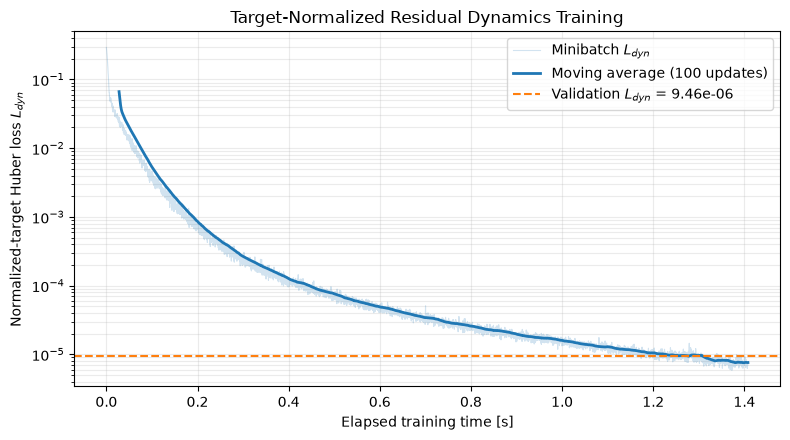

In [22]:
# lax.scan returns one loss per optimizer update. Distribute the measured
# compiled runtime over those updates to obtain elapsed training time.
elapsed_training_time = jnp.linspace(
    0.0, training_duration_seconds, training_losses.shape[0]
)
loss_for_plot = jnp.maximum(training_losses, 1e-12)

smoothing_window = min(100, training_losses.shape[0])
smoothing_kernel = jnp.ones(smoothing_window) / smoothing_window
smoothed_loss = jnp.convolve(
    loss_for_plot, smoothing_kernel, mode="valid"
)
smoothed_time = elapsed_training_time[smoothing_window - 1:]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    elapsed_training_time, loss_for_plot,
    color="tab:blue", alpha=0.2, linewidth=0.8, label="Minibatch $L_{dyn}$"
)
ax.plot(
    smoothed_time, smoothed_loss,
    color="tab:blue", linewidth=2.0,
    label=f"Moving average ({smoothing_window} updates)"
)
ax.axhline(
    validation_loss, color="tab:orange", linestyle="--",
    label=f"Validation $L_{{dyn}}$ = {validation_loss:.2e}"
)
ax.set_xlabel("Elapsed training time [s]")
ax.set_ylabel("Normalized-target Huber loss $L_{dyn}$")
ax.set_yscale("log")
ax.set_title("Target-Normalized Residual Dynamics Training")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 9. Test Five Hidden Wind Conditions at the Same State

In [23]:
# Use zero and four cardinal unit accelerations. Each row retrieves the
# immutable latent associated with that condition; w itself is not a model input.
test_condition_indices = jnp.array([0, 1, 3, 5, 7])
test_pairs = eval_env.wind_z_table[test_condition_indices]
test_hidden_accelerations = test_pairs[:, :3]
test_latents = test_pairs[:, 3:]

# Hold s_t and a_t exactly fixed across all five tests.
fixed_state_action = dataset["state_action"][validation_indices[0]]
fixed_normalized_input = (fixed_state_action - input_mean) / input_std
fixed_inputs = jnp.broadcast_to(
    fixed_normalized_input, (test_condition_indices.shape[0], 14)
)

test_residual_predictions_norm = residual_model.apply(
    residual_train_state.params, fixed_inputs, test_latents
)
test_residual_predictions = (
    test_residual_predictions_norm * residual_target_std
    + residual_target_mean
)

# Five explicit tests: every condition-associated prediction must differ from
# all four predictions produced for the other hidden conditions.
prediction_tolerance = 1e-6
for test_idx in range(test_condition_indices.shape[0]):
    other_predictions = jnp.concatenate(
        [
            test_residual_predictions[:test_idx],
            test_residual_predictions[test_idx + 1:],
        ],
        axis=0,
    )
    distances = jnp.linalg.norm(
        other_predictions - test_residual_predictions[test_idx], axis=-1
    )
    assert jnp.all(distances > prediction_tolerance), (
        f"Condition {test_idx} produced a collapsed residual prediction. "
        "The training data may not contain condition-dependent dynamics."
    )

assert jnp.unique(test_hidden_accelerations, axis=0).shape[0] == 5
assert jnp.unique(test_latents, axis=0).shape[0] == 5

print(f"Fixed state-action: {fixed_state_action}")
for acceleration, prediction in zip(
    test_hidden_accelerations, test_residual_predictions
):
    print(
        f"hidden acceleration={acceleration} "
        f"-> predicted [delta_p, delta_v]={prediction}"
    )
print("All five hidden-condition tests passed.")

Fixed state-action: [ 1.50187731e+00 -2.93386936e-01  1.51830566e+00  9.87992287e-01
 -4.79716882e-02 -1.22200064e-02 -1.46357358e-01  9.87155922e-03
 -2.34715641e-04 -8.56127124e-03  1.89661431e+00 -1.25324745e-02
  2.04801857e-02  3.94575018e-03]
hidden acceleration=[0. 0. 0.] -> predicted [delta_p, delta_v]=[ 2.0511761e-06 -1.1592483e-05  7.6493452e-14  3.5005622e-05
 -1.0676453e-03  5.9738139e-12]
hidden acceleration=[1. 0. 0.] -> predicted [delta_p, delta_v]=[ 1.9360619e-04 -4.5147281e-06 -3.6785353e-12  1.9195970e-02
 -4.7285447e-04  1.6929070e-12]
hidden acceleration=[-4.371139e-08  1.000000e+00  0.000000e+00] -> predicted [delta_p, delta_v]=[ 7.1756222e-06  1.6691309e-04  7.5696172e-11 -6.8038702e-05
  1.6140807e-02 -5.1548314e-11]
hidden acceleration=[-1.000000e+00 -8.742278e-08  0.000000e+00] -> predicted [delta_p, delta_v]=[-1.8340725e-04 -1.1864631e-07 -1.3678587e-10 -1.8466135e-02
 -1.9859860e-04 -6.5150533e-12]
hidden acceleration=[ 1.1924881e-08 -1.0000000e+00  0.0000000

## 10. Evaluate Predicted Residuals on Fresh Policy Rollouts

Held-out transitions: 16,000
Learned-model normalized-target Huber L_dyn: 1.843637e-04
Zero-residual normalized-target Huber loss:   2.985590e-01
delta_px: MAE=1.519e-06, RMSE=4.582e-06, R2=1.000
delta_py: MAE=1.720e-06, RMSE=5.808e-06, R2=0.999
delta_pz: MAE=3.027e-11, RMSE=8.296e-11, R2=1.000
delta_vx: MAE=1.434e-04, RMSE=4.210e-04, R2=1.000
delta_vy: MAE=1.690e-04, RMSE=5.342e-04, R2=0.999
delta_vz: MAE=3.106e-11, RMSE=9.092e-11, R2=1.000


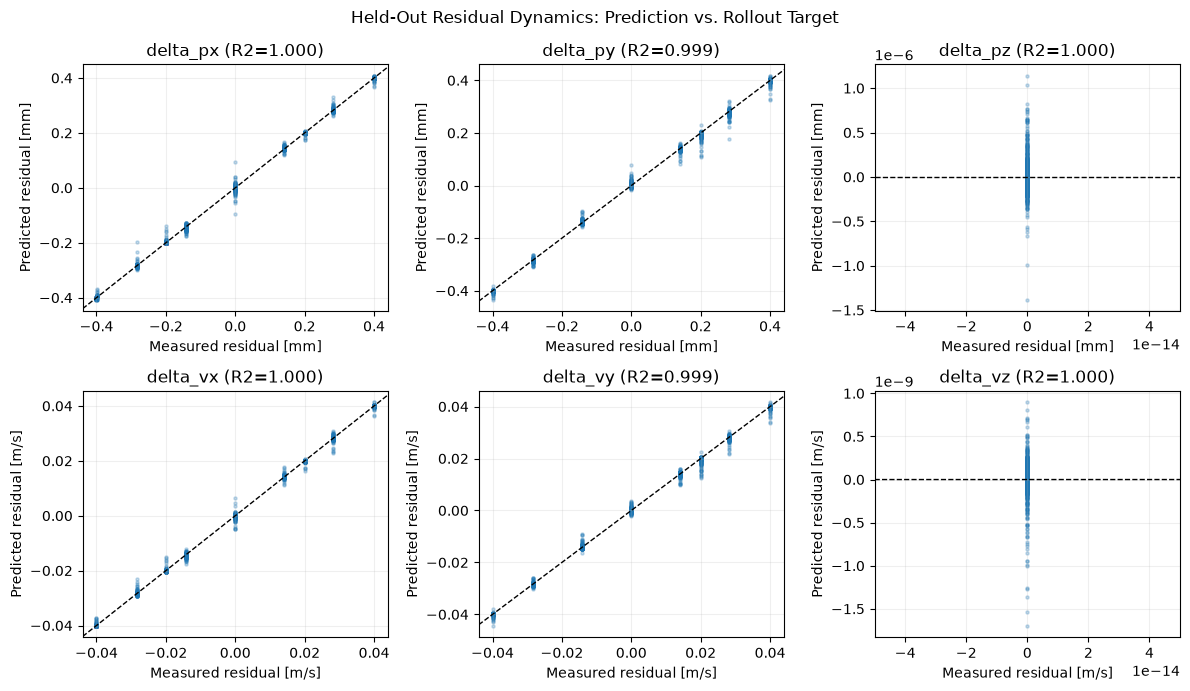

In [24]:
# Generate a held-out dataset with RNG keys that were never used for training.
num_test_rollouts = 64
key, key_test_rollouts = jax.random.split(key)
test_rollout_keys = jax.random.split(key_test_rollouts, num_test_rollouts)
test_trajectories = parallel_rollout(
    eval_env, test_rollout_keys, policy_trained, dummy_residual_params
)

test_env_states = test_trajectories.state
test_quad_states = test_env_states.quadrotor_state
test_states = state_vectors(
    test_quad_states.p[:, :-1],
    test_quad_states.R[:, :-1],
    test_quad_states.v[:, :-1],
)
test_actions = test_env_states.last_actions[:, 1:, -1, :]
test_state_actions = jnp.concatenate([test_states, test_actions], axis=-1)
test_done = jnp.logical_or(
    test_trajectories.terminated[:, 1:],
    test_trajectories.truncated[:, 1:],
)
test_valid_transition = (jnp.cumsum(test_done, axis=1) - test_done) == 0

# Evaluate the analytical prior from exactly the same pre-transition states.
test_transition_states = jax.tree.map(
    lambda leaf: leaf[:, :-1][test_valid_transition], test_env_states
)
test_observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:][test_valid_transition], test_quad_states
)
test_actions = test_actions[test_valid_transition]
test_state_actions = test_state_actions[test_valid_transition]
test_latent_z = test_env_states.latent_z[:, :-1][test_valid_transition]

key, key_test_prior = jax.random.split(key)
test_prior_keys = jax.random.split(
    key_test_prior, test_state_actions.shape[0]
)
test_prior_next_quad_states = evaluate_prior(
    test_transition_states, test_actions, test_prior_keys
)

# Ground-truth held-out residual: s_next minus the analytical prior. For
# hovering this is Euclidean position and velocity difference.
test_residual_targets = state_difference(
    test_observed_next_quad_states,
    test_prior_next_quad_states,
    include_orientation=residual_model.predict_orientation,
)
test_normalized_inputs = (test_state_actions - input_mean) / input_std
test_residual_predictions_norm = residual_model.apply(
    residual_train_state.params, test_normalized_inputs, test_latent_z
)
test_residual_predictions = (
    test_residual_predictions_norm * residual_target_std
    + residual_target_mean
)

# L_dyn is evaluated in normalized target coordinates, exactly as in training.
# Physical-unit predictions are retained for MAE, RMSE, R2, and plots.
test_residual_targets_norm = (
    test_residual_targets - residual_target_mean
) / residual_target_std
zero_residual_predictions_norm = (
    jnp.zeros_like(test_residual_targets) - residual_target_mean
) / residual_target_std

# Quantitative comparison against both ground truth and a zero-residual model.
test_errors = test_residual_predictions - test_residual_targets
test_huber_loss = optax.huber_loss(
    test_residual_predictions_norm,
    test_residual_targets_norm,
    delta=huber_delta,
).mean()
zero_model_huber_loss = optax.huber_loss(
    zero_residual_predictions_norm,
    test_residual_targets_norm,
    delta=huber_delta,
).mean()
component_mae = jnp.mean(jnp.abs(test_errors), axis=0)
component_rmse = jnp.sqrt(jnp.mean(test_errors**2, axis=0))
sum_squared_error = jnp.sum(test_errors**2, axis=0)
sum_squared_total = jnp.sum(
    (test_residual_targets - test_residual_targets.mean(axis=0)) ** 2,
    axis=0,
)
component_r2 = 1.0 - sum_squared_error / jnp.maximum(
    sum_squared_total, 1e-12
)

assert test_residual_predictions.shape == test_residual_targets.shape
assert jnp.all(jnp.isfinite(test_residual_predictions))
assert test_huber_loss < zero_model_huber_loss, (
    "The learned residual model does not outperform the analytical prior "
    "on fresh rollouts."
)

print(f"Held-out transitions: {test_residual_targets.shape[0]:,}")
print(f"Learned-model normalized-target Huber L_dyn: {test_huber_loss:.6e}")
print(f"Zero-residual normalized-target Huber loss:   {zero_model_huber_loss:.6e}")
for name, mae, rmse, r2 in zip(
    component_names, component_mae, component_rmse, component_r2
):
    print(f"{name:>8s}: MAE={mae:.3e}, RMSE={rmse:.3e}, R2={r2:.3f}")

# Predicted-versus-measured residual plots. Position is displayed in mm so
# its O(dt^2) one-step residual is visible. Measured and predicted axes use
# their own data limits so a larger prediction range cannot flatten targets.
plot_stride = max(1, test_residual_targets.shape[0] // 5000)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

def padded_data_limits(values):
    lower = float(values.min())
    upper = float(values.max())
    span = max(upper - lower, 1e-3 * max(abs(lower), abs(upper)), 1e-12)
    padding = 0.05 * span
    return lower - padding, upper + padding

for component_idx, (axis, component_name) in enumerate(
    zip(axes.flat, component_names)
):
    display_scale = 1000.0 if component_idx < 3 else 1.0
    display_unit = "mm" if component_idx < 3 else "m/s"
    target_component = (
        test_residual_targets[::plot_stride, component_idx] * display_scale
    )
    predicted_component = (
        test_residual_predictions[::plot_stride, component_idx] * display_scale
    )
    measured_limits = padded_data_limits(target_component)
    predicted_limits = padded_data_limits(predicted_component)
    axis.scatter(
        target_component, predicted_component, s=5, alpha=0.25
    )
    identity_lower = max(measured_limits[0], predicted_limits[0])
    identity_upper = min(measured_limits[1], predicted_limits[1])
    if identity_lower < identity_upper:
        axis.plot(
            [identity_lower, identity_upper],
            [identity_lower, identity_upper],
            "k--", linewidth=1, label="Ideal"
        )
    axis.set_xlim(*measured_limits)
    axis.set_ylim(*predicted_limits)
    axis.set_title(f"{component_name} (R2={component_r2[component_idx]:.3f})")
    axis.set_xlabel(f"Measured residual [{display_unit}]")
    axis.set_ylabel(f"Predicted residual [{display_unit}]")
    axis.grid(True, alpha=0.2)

fig.suptitle("Held-Out Residual Dynamics: Prediction vs. Rollout Target")
fig.tight_layout()
plt.show()

### Fixed $w=[1,0,0]$ Latent Across Diverse Held-Out Inputs

Fixed acceleration: [1. 0. 0.]
Fixed corresponding latent: [-2.3250308  -0.21879166 -1.245911   -0.7322674  -0.544259   -0.31630015
  0.41163054  1.0425134  -0.12853466  1.3664634  -0.6651947   0.35151008]
Held-out state-action pairs tested: 512
Selected raw state-action standard deviations:
[0.38331598 0.4126716  0.1836215  0.00530484 0.06405375 0.06123647
 0.08993439 0.2646386  0.30582735 0.29734653 0.16383514 0.26017386
 0.25190103 0.00636027]
Expected [delta_p, delta_v]: [0.0002 0.     0.     0.02   0.     0.    ]
Prediction mean:              [ 1.9653462e-04 -1.6888680e-06 -4.6950425e-12  1.9594988e-02
 -1.3021447e-04 -1.1130484e-11]
Prediction std:               [5.6802273e-06 3.4364386e-06 7.2771518e-11 6.2983349e-04 3.5708377e-04
 8.4296160e-11]
RMSE from expected:           [6.6538614e-06 3.8290191e-06 7.2922821e-11 7.4881571e-04 3.8008505e-04
 8.5027818e-11]
Norm of mean delta_p error:   3.855013e-06 m
Norm of mean delta_v error:   4.254295e-04 m/s
First 20 predicted [delta_p

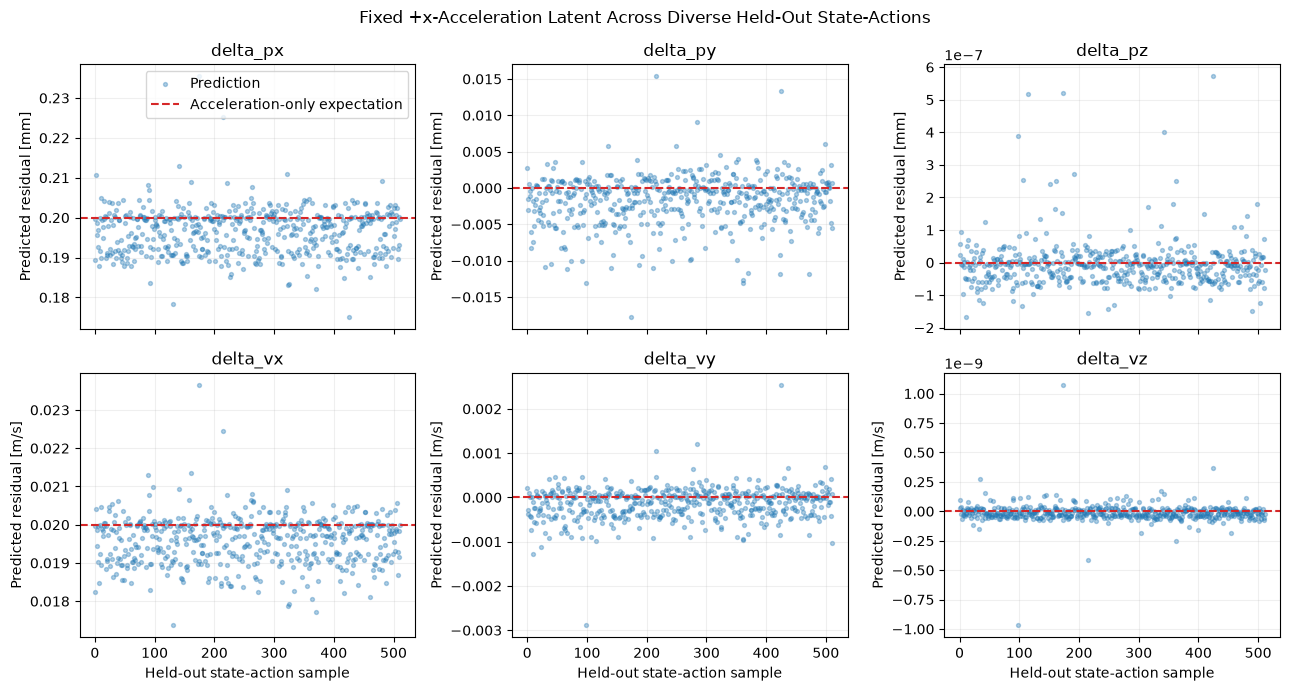

In [25]:
# Retrieve the unique latent paired with the +x unit acceleration. Keep this
# condition fixed while changing only the held-out state-action input.
unit_x_acceleration = jnp.array([1.0, 0.0, 0.0])
unit_x_matches = jnp.all(
    jnp.isclose(eval_env.wind_z_table[:, :3], unit_x_acceleration), axis=-1
)
assert unit_x_matches.sum() == 1
unit_x_latent = eval_env.wind_z_table[jnp.argmax(unit_x_matches), 3:]

# Randomly select hundreds of fresh, valid state-action pairs without
# replacement. These inputs span different rollouts, times, and wind cases;
# the latent supplied to the residual network is nevertheless always +x.
num_fixed_latent_tests = min(512, test_normalized_inputs.shape[0])
key, key_fixed_latent_test = jax.random.split(key)
fixed_latent_test_indices = jax.random.choice(
    key_fixed_latent_test,
    test_normalized_inputs.shape[0],
    shape=(num_fixed_latent_tests,),
    replace=False,
)
fixed_latent_test_inputs = test_normalized_inputs[
    fixed_latent_test_indices
]
fixed_unit_x_latents = jnp.broadcast_to(
    unit_x_latent, (num_fixed_latent_tests, unit_x_latent.shape[0])
)
fixed_latent_predictions_norm = residual_model.apply(
    residual_train_state.params,
    fixed_latent_test_inputs,
    fixed_unit_x_latents,
)
fixed_latent_predictions = (
    fixed_latent_predictions_norm * residual_target_std
    + residual_target_mean
)
assert fixed_latent_predictions.shape == (num_fixed_latent_tests, 6)

# If the residual represented only the constant hidden acceleration, one
# transition would contribute delta_p=0.5*w*dt^2 and delta_v=w*dt.
expected_unit_x_position = 0.5 * unit_x_acceleration * sim_dt**2
expected_unit_x_velocity = unit_x_acceleration * sim_dt
expected_unit_x_residual = jnp.concatenate(
    [expected_unit_x_position, expected_unit_x_velocity]
)
prediction_mean = fixed_latent_predictions.mean(axis=0)
prediction_std = fixed_latent_predictions.std(axis=0)
prediction_rmse_from_expected = jnp.sqrt(
    jnp.mean(
        (fixed_latent_predictions - expected_unit_x_residual) ** 2, axis=0
    )
)
position_mean_error = jnp.linalg.norm(
    prediction_mean[:3] - expected_unit_x_position
)
velocity_mean_error = jnp.linalg.norm(
    prediction_mean[3:6] - expected_unit_x_velocity
)
per_sample_position_error = jnp.linalg.norm(
    fixed_latent_predictions[:, :3] - expected_unit_x_position, axis=-1
)
per_sample_velocity_error = jnp.linalg.norm(
    fixed_latent_predictions[:, 3:6] - expected_unit_x_velocity, axis=-1
)

print(f"Fixed acceleration: {unit_x_acceleration}")
print(f"Fixed corresponding latent: {unit_x_latent}")
print(f"Held-out state-action pairs tested: {num_fixed_latent_tests}")
print(
    "Selected raw state-action standard deviations:\n"
    f"{test_state_actions[fixed_latent_test_indices].std(axis=0)}"
)
print(f"Expected [delta_p, delta_v]: {expected_unit_x_residual}")
print(f"Prediction mean:              {prediction_mean}")
print(f"Prediction std:               {prediction_std}")
print(f"RMSE from expected:           {prediction_rmse_from_expected}")
print(f"Norm of mean delta_p error:   {position_mean_error:.6e} m")
print(f"Norm of mean delta_v error:   {velocity_mean_error:.6e} m/s")
print("First 20 predicted [delta_p, delta_v] residuals:")
for prediction_idx, prediction in enumerate(fixed_latent_predictions[:20]):
    print(f"  {prediction_idx:02d}: {prediction}")

# A compact empirical assessment. This is intentionally reported rather than
# asserted because the learned target also contains high-/low-fidelity model
# mismatch, so it need not equal the acceleration-only formula exactly.
position_tolerance = 5e-4  # m
velocity_tolerance = 5e-3  # m/s
fraction_within_tolerance = jnp.mean(
    (per_sample_position_error <= position_tolerance)
    & (per_sample_velocity_error <= velocity_tolerance)
)
approximately_matches_acceleration_only = bool(
    fraction_within_tolerance >= 0.95
)
print(
    f"Predictions within both tolerances: "
    f"{100.0 * fraction_within_tolerance:.1f}%"
)
print(
    "Acceleration-only mean prediction assessment: "
    + ("PASS" if approximately_matches_acceleration_only else "FAIL")
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
test_number = jnp.arange(num_fixed_latent_tests)
for component_idx, (axis, component_name) in enumerate(
    zip(axes.flat, component_names)
):
    display_scale = 1000.0 if component_idx < 3 else 1.0
    display_unit = "mm" if component_idx < 3 else "m/s"
    axis.scatter(
        test_number,
        fixed_latent_predictions[:, component_idx] * display_scale,
        s=8, alpha=0.35, color="tab:blue", label="Prediction",
    )
    axis.axhline(
        expected_unit_x_residual[component_idx] * display_scale,
        color="tab:red", linestyle="--", linewidth=1.5,
        label="Acceleration-only expectation",
    )
    axis.set_title(component_name)
    axis.set_ylabel(f"Predicted residual [{display_unit}]")
    axis.grid(True, alpha=0.2)
for axis in axes[-1]:
    axis.set_xlabel("Held-out state-action sample")
axes[0, 0].legend()
fig.suptitle(
    "Fixed +x-Acceleration Latent Across Diverse Held-Out State-Actions"
)
fig.tight_layout()
plt.show()

## 11. Evaluate Multi-Step Residual-Dynamics Rollouts

Overall open-loop multi-step RMSE
  Position: residual=0.1007 m, 
  Velocity: residual=0.0377 m/s, 
t=0.5s | position residual/prior: 0.0100/0.1836 m | velocity residual/prior: 0.0293/0.7344 m/s
t=1.0s | position residual/prior: 0.0254/0.7344 m | velocity residual/prior: 0.0327/1.4688 m/s
t=2.0s | position residual/prior: 0.0559/2.9375 m | velocity residual/prior: 0.0296/2.9375 m/s
t=5.0s | position residual/prior: 0.1181/18.3594 m | velocity residual/prior: 0.0258/7.3437 m/s


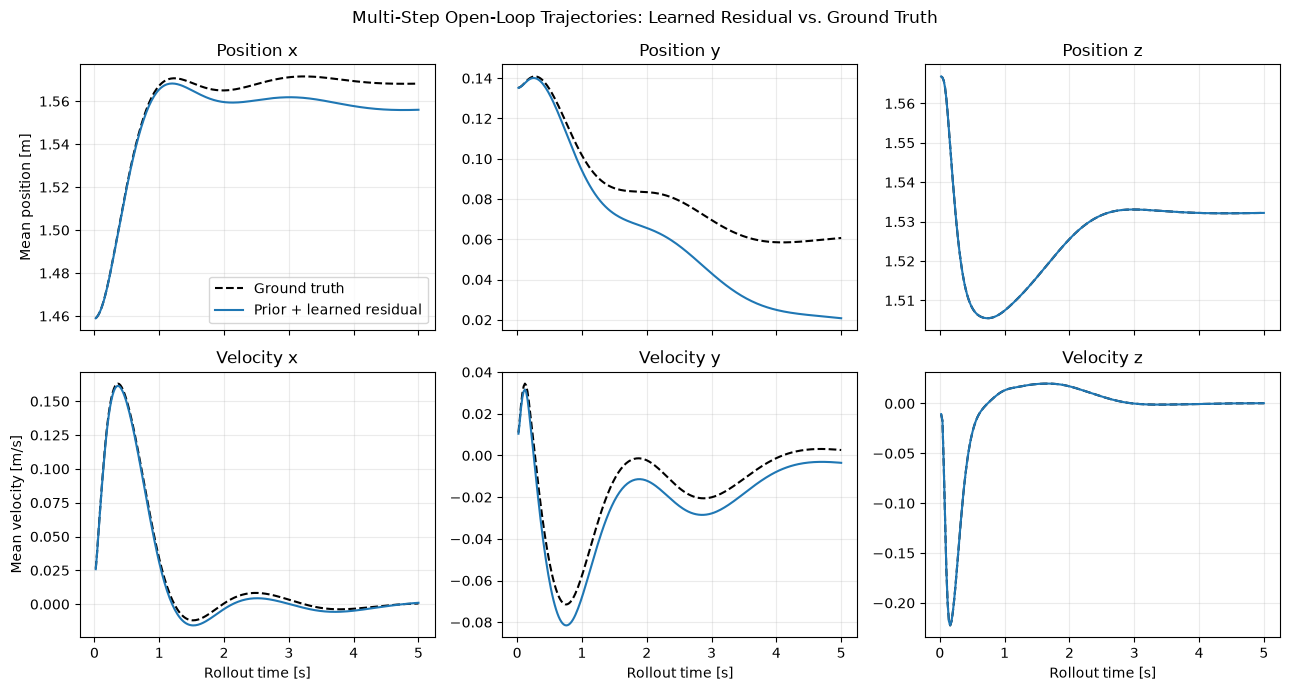

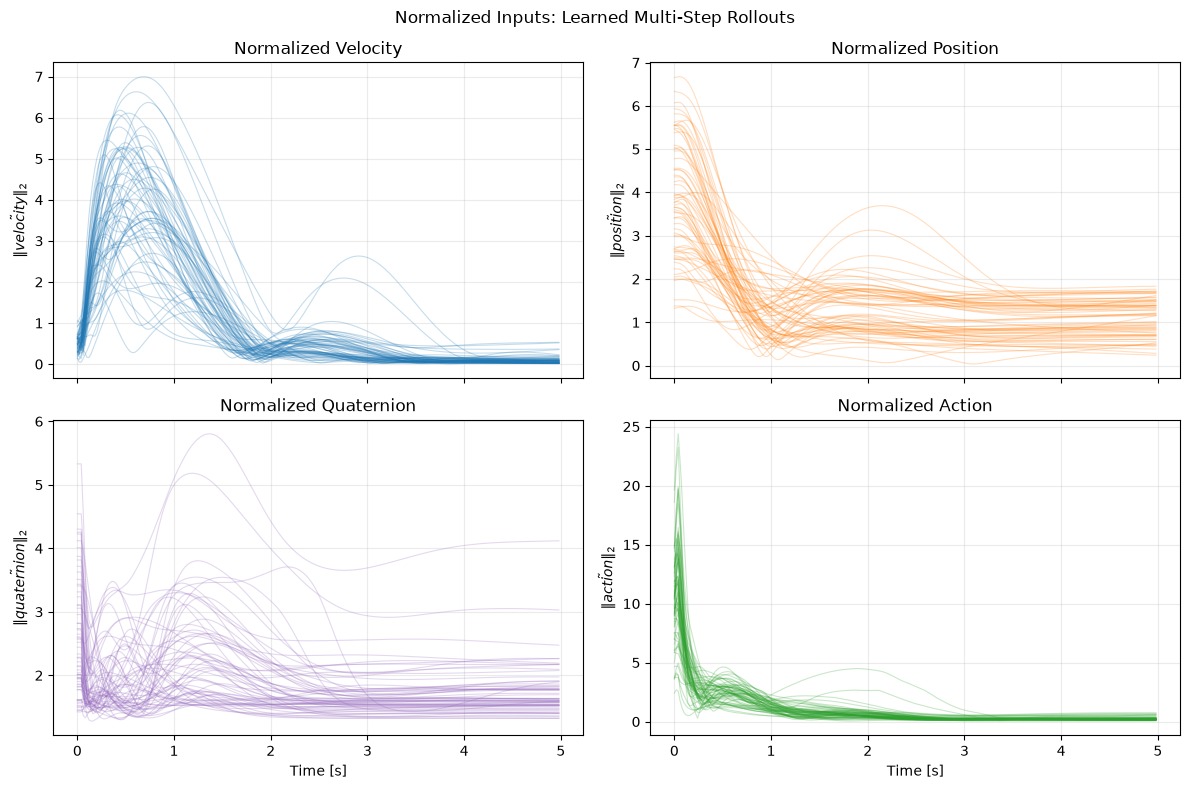

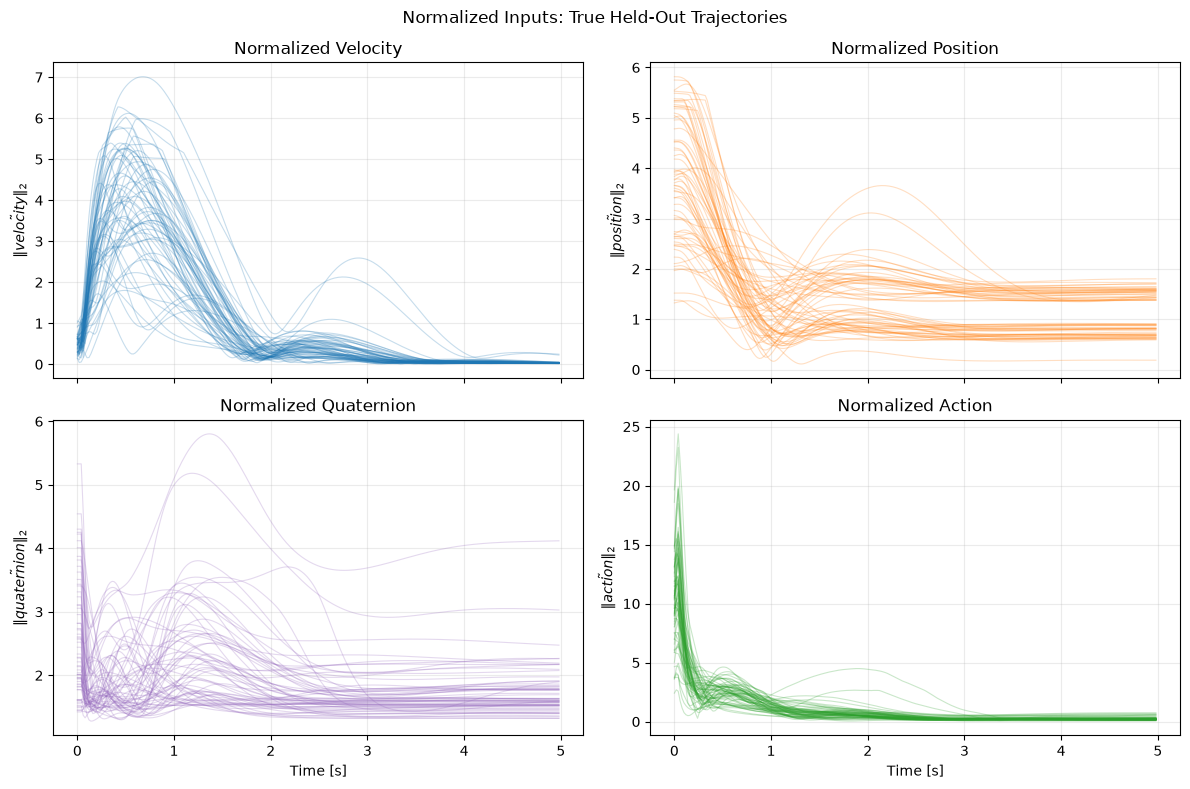

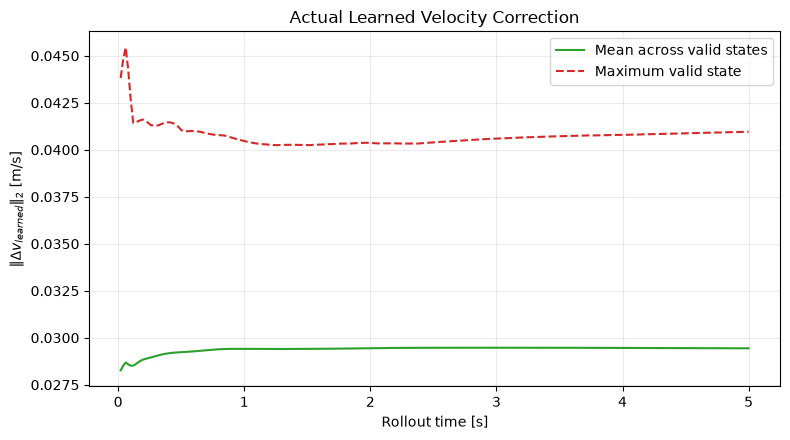

Peak applied velocity correction: 0.045445 m/s


In [30]:
# Reuse the fresh held-out trajectories from section 10. Starting from each
# true initial state, recursively advance f_prior through the recorded action
# sequence and add the learned residual after every analytical transition.
rollout_horizon = test_env_states.time.shape[1] - 1
rollout_actions = test_env_states.last_actions[:, 1:, -1, :]
actions_by_time = jnp.swapaxes(rollout_actions, 0, 1)
initial_rollout_states = jax.tree.map(lambda leaf: leaf[:, 0], test_env_states)
rollout_latents = initial_rollout_states.latent_z
key, key_model_rollouts = jax.random.split(key)
model_rollout_keys = jax.random.split(
    key_model_rollouts, (rollout_horizon, num_test_rollouts)
)

def clip_residual_network_inputs(normalized_inputs):
    # State-action layout: position[0:3], quaternion[3:7],
    # velocity[7:10], action[10:14]. Clip only p and v.
    normalized_inputs = normalized_inputs.at[..., 0:3].set(
        jnp.clip(normalized_inputs[..., 0:3], -5.0, 5.0)
    )
    return normalized_inputs.at[..., 7:10].set(
        jnp.clip(normalized_inputs[..., 7:10], -5.0, 5.0)
    )

@jax.jit
def predict_multi_step_rollout(
    initial_states, actions, latents, step_keys,
    position_residual_scale, velocity_residual_scale
):
    def rollout_step(predicted_states, step_inputs):
        step_actions, keys_at_step = step_inputs

        # Advance the nominal model, including the same command-delay buffer.
        prior_transitions = jax.vmap(
            prior_env._step, in_axes=(0, 0, None, 0)
        )(predicted_states, step_actions, {}, keys_at_step)
        prior_states = prior_transitions.state

        # D_psi is evaluated on the recursively predicted state, not on the
        # ground-truth state (no teacher forcing).
        predicted_quad_states = predicted_states.quadrotor_state
        predicted_state_vectors = state_vectors(
            predicted_quad_states.p,
            predicted_quad_states.R,
            predicted_quad_states.v,
        )
        predicted_state_actions = jnp.concatenate(
            [predicted_state_vectors, step_actions], axis=-1
        )
        normalized_state_actions = (
            predicted_state_actions - input_mean
        ) / input_std
        # normalized_state_actions = clip_residual_network_inputs(
        #     normalized_state_actions
        # )
        normalized_residual_correction = residual_model.apply(
            residual_train_state.params, normalized_state_actions, latents
        )
        residual_correction = (
            normalized_residual_correction * residual_target_std
            + residual_target_mean
        )
        position_correction = (
            position_residual_scale * residual_correction[:, :3]
        )
        velocity_correction = (
            velocity_residual_scale * residual_correction[:, 3:6]
        )

        prior_quad_states = prior_states.quadrotor_state
        corrected_quad_states = prior_quad_states.replace(
            p=prior_quad_states.p + position_correction,
            v=prior_quad_states.v + velocity_correction,
        )
        corrected_states = prior_states.replace(
            quadrotor_state=corrected_quad_states
        )
        predicted_output = (
            corrected_quad_states.p,
            corrected_quad_states.v,
            velocity_correction,
            normalized_state_actions,
        )
        return corrected_states, predicted_output

    _, rollout_outputs = jax.lax.scan(
        rollout_step, initial_states, (actions, step_keys)
    )
    return rollout_outputs

# Unit scales evaluate the complete learned residual; zero scales give an
# identical analytical-prior baseline. Scan outputs are time-major.
(predicted_positions, predicted_velocities,
 learned_velocity_corrections, normalized_rollout_inputs) = (
    predict_multi_step_rollout(
        initial_rollout_states,
        actions_by_time,
        rollout_latents,
        model_rollout_keys,
        1.0,
        1.0,
    )
)
(prior_positions, prior_velocities, _, _) = predict_multi_step_rollout(
    initial_rollout_states,
    actions_by_time,
    rollout_latents,
    model_rollout_keys,
    0.0,
    0.0,
)

# Convert predictions to [environment, time, xyz] and compare only valid
# pre-termination portions of the held-out trajectories.
predicted_positions = jnp.swapaxes(predicted_positions, 0, 1)
predicted_velocities = jnp.swapaxes(predicted_velocities, 0, 1)
learned_velocity_corrections = jnp.swapaxes(
    learned_velocity_corrections, 0, 1
)
normalized_rollout_inputs = jnp.swapaxes(
    normalized_rollout_inputs, 0, 1
)
prior_positions = jnp.swapaxes(prior_positions, 0, 1)
prior_velocities = jnp.swapaxes(prior_velocities, 0, 1)
true_positions = test_quad_states.p[:, 1:]
true_velocities = test_quad_states.v[:, 1:]
multi_step_valid = test_valid_transition

residual_position_error = jnp.linalg.norm(
    predicted_positions - true_positions, axis=-1
)
prior_position_error = jnp.linalg.norm(
    prior_positions - true_positions, axis=-1
)
residual_velocity_error = jnp.linalg.norm(
    predicted_velocities - true_velocities, axis=-1
)
prior_velocity_error = jnp.linalg.norm(
    prior_velocities - true_velocities, axis=-1
)

def masked_time_mean(values, valid):
    valid_count = jnp.maximum(valid.sum(axis=0), 1)
    return jnp.where(valid, values, 0.0).sum(axis=0) / valid_count

def masked_time_max(values, valid):
    maxima = jnp.where(valid, values, -jnp.inf).max(axis=0)
    return jnp.where(valid.any(axis=0), maxima, jnp.nan)

def masked_rmse(vector_error, valid):
    squared_norm = jnp.sum(vector_error**2, axis=-1)
    return jnp.sqrt(
        jnp.where(valid, squared_norm, 0.0).sum()
        / jnp.maximum(valid.sum(), 1)
    )

residual_position_curve = masked_time_mean(
    residual_position_error, multi_step_valid
)
prior_position_curve = masked_time_mean(
    prior_position_error, multi_step_valid
)
residual_velocity_curve = masked_time_mean(
    residual_velocity_error, multi_step_valid
)
prior_velocity_curve = masked_time_mean(
    prior_velocity_error, multi_step_valid
)

residual_position_rmse = masked_rmse(
    predicted_positions - true_positions, multi_step_valid
)
prior_position_rmse = masked_rmse(
    prior_positions - true_positions, multi_step_valid
)
residual_velocity_rmse = masked_rmse(
    predicted_velocities - true_velocities, multi_step_valid
)
prior_velocity_rmse = masked_rmse(
    prior_velocities - true_velocities, multi_step_valid
)

print("Overall open-loop multi-step RMSE")
print(
    f"  Position: residual={residual_position_rmse:.4f} m, "
   )
print(
    f"  Velocity: residual={residual_velocity_rmse:.4f} m/s, "
)
for horizon_seconds in (0.5, 1.0, 2.0, 5.0):
    horizon_idx = min(
        int(round(horizon_seconds / sim_dt)) - 1, rollout_horizon - 1
    )
    print(
        f"t={horizon_seconds:>3.1f}s | "
        f"position residual/prior: "
        f"{residual_position_curve[horizon_idx]:.4f}/"
        f"{prior_position_curve[horizon_idx]:.4f} m | "
        f"velocity residual/prior: "
        f"{residual_velocity_curve[horizon_idx]:.4f}/"
        f"{prior_velocity_curve[horizon_idx]:.4f} m/s"
    )

rollout_time = sim_dt * jnp.arange(1, rollout_horizon + 1)
network_input_time = sim_dt * jnp.arange(rollout_horizon)
def masked_time_component_mean(values, valid):
    expanded_valid = valid[..., None]
    valid_count = jnp.maximum(valid.sum(axis=0), 1)[:, None]
    return jnp.where(expanded_valid, values, 0.0).sum(axis=0) / valid_count

mean_predicted_positions = masked_time_component_mean(
    predicted_positions, multi_step_valid
)
mean_true_positions = masked_time_component_mean(
    true_positions, multi_step_valid
)
mean_predicted_velocities = masked_time_component_mean(
    predicted_velocities, multi_step_valid
)
mean_true_velocities = masked_time_component_mean(
    true_velocities, multi_step_valid
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for component_idx, component_label in enumerate(("x", "y", "z")):
    position_axis = axes[0, component_idx]
    velocity_axis = axes[1, component_idx]
    position_axis.plot(
        rollout_time, mean_true_positions[:, component_idx],
        color="black", linestyle="--", label="Ground truth"
    )
    position_axis.plot(
        rollout_time, mean_predicted_positions[:, component_idx],
        color="tab:blue", label="Prior + learned residual"
    )
    velocity_axis.plot(
        rollout_time, mean_true_velocities[:, component_idx],
        color="black", linestyle="--", label="Ground truth"
    )
    velocity_axis.plot(
        rollout_time, mean_predicted_velocities[:, component_idx],
        color="tab:blue", label="Prior + learned residual"
    )
    position_axis.set_title(f"Position {component_label}")
    velocity_axis.set_title(f"Velocity {component_label}")
    velocity_axis.set_xlabel("Rollout time [s]")
    position_axis.grid(True, alpha=0.25)
    velocity_axis.grid(True, alpha=0.25)
axes[0, 0].set_ylabel("Mean position [m]")
axes[1, 0].set_ylabel("Mean velocity [m/s]")
axes[0, 0].legend()
fig.suptitle(
    "Multi-Step Open-Loop Trajectories: Learned Residual vs. Ground Truth"
)
fig.tight_layout()
plt.show()

# Apply the same normalization and p/v clipping to every true held-out
# pre-transition state and recorded action for a like-for-like diagnostic.
true_state_vectors = state_vectors(
    test_quad_states.p[:, :-1],
    test_quad_states.R[:, :-1],
    test_quad_states.v[:, :-1],
)
true_state_actions = jnp.concatenate(
    [true_state_vectors, rollout_actions], axis=-1
)
normalized_true_inputs = clip_residual_network_inputs(
    (true_state_actions - input_mean) / input_std
)

# This is the physical correction actually added to v after every prior
# transition (velocity_residual_scale=1), rather than its normalized value.
learned_velocity_correction_magnitudes = jnp.linalg.norm(
    learned_velocity_corrections, axis=-1
)
mean_velocity_correction_curve = masked_time_mean(
    learned_velocity_correction_magnitudes, multi_step_valid
)
max_velocity_correction_curve = masked_time_max(
    learned_velocity_correction_magnitudes, multi_step_valid
)

# State-vector layout is [position(3), quaternion(4), velocity(3), action(4)].
# Plot every valid rollout separately so no maximum or mean hides individual
# normalized network inputs. Each panel shows the norm of one input group.
normalized_input_groups = (
    ("Velocity", 7, 10, "tab:blue"),
    ("Position", 0, 3, "tab:orange"),
    ("Quaternion", 3, 7, "tab:purple"),
    ("Action", 10, 14, "tab:green"),
)

def plot_normalized_input_groups(normalized_inputs, figure_title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for axis, (name, start, stop, color) in zip(
        axes.flat, normalized_input_groups
    ):
        group_norms = jnp.linalg.norm(
            normalized_inputs[..., start:stop], axis=-1
        )
        valid_group_norms = jnp.where(
            multi_step_valid, group_norms, jnp.nan
        )
        axis.plot(
            network_input_time, valid_group_norms.T,
            color=color, alpha=0.25, linewidth=0.8
        )
        axis.set_title(f"Normalized {name}")
        axis.set_ylabel(rf"$\|\tilde{{{name.lower()}}}\|_2$")
        axis.grid(True, alpha=0.25)
    for axis in axes[-1]:
        axis.set_xlabel("Time [s]")
    fig.suptitle(figure_title)
    fig.tight_layout()
    plt.show()

plot_normalized_input_groups(
    normalized_rollout_inputs,
    "Normalized Inputs: Learned Multi-Step Rollouts",
)
plot_normalized_input_groups(
    normalized_true_inputs,
    "Normalized Inputs: True Held-Out Trajectories",
)

fig, correction_axis = plt.subplots(figsize=(8, 4.5))
correction_axis.plot(
    rollout_time, mean_velocity_correction_curve,
    color="tab:green", label="Mean across valid states"
)
correction_axis.plot(
    rollout_time, max_velocity_correction_curve,
    color="tab:red", linestyle="--", label="Maximum valid state"
)
correction_axis.set_xlabel("Rollout time [s]")
correction_axis.set_ylabel(r"$\|\Delta v_{learned}\|_2$ [m/s]")
correction_axis.set_title("Actual Learned Velocity Correction")
correction_axis.grid(True, alpha=0.25)
correction_axis.legend()
fig.tight_layout()
plt.show()

print(
    "Peak applied velocity correction: "
    f"{jnp.nanmax(max_velocity_correction_curve):.6f} m/s"
)

## 12. Multi-Step Rollouts with the Predicted Position Residual Disabled

Overall open-loop multi-step RMSE
  Position | prior=8.7713 m, full residual=0.1007 m, velocity-only residual=0.1204 m
  Velocity | prior=4.5205 m/s, full residual=0.0377 m/s, velocity-only residual=0.0400 m/s
t=0.5s | position velocity-only/full/prior: 0.0141/0.0100/0.1836 m | velocity velocity-only/full/prior: 0.0293/0.0293/0.7344 m/s
t=1.0s | position velocity-only/full/prior: 0.0332/0.0254/0.7344 m | velocity velocity-only/full/prior: 0.0327/0.0327/1.4688 m/s
t=2.0s | position velocity-only/full/prior: 0.0707/0.0559/2.9375 m | velocity velocity-only/full/prior: 0.0301/0.0296/2.9375 m/s
t=5.0s | position velocity-only/full/prior: 0.1478/0.1181/18.3594 m | velocity velocity-only/full/prior: 0.0341/0.0258/7.3437 m/s


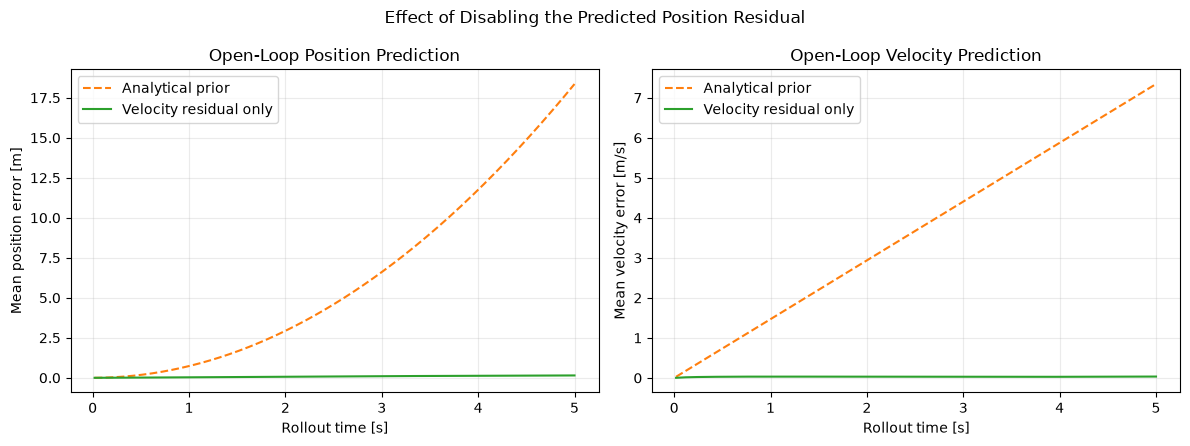

In [28]:
# Keep the learned velocity correction but explicitly force delta_p_pred=0.
# Position can still improve indirectly at later steps because the corrected
# velocity is propagated through p_dot=v by the analytical prior.
(velocity_only_positions, velocity_only_velocities, _, _) = (
    predict_multi_step_rollout(
        initial_rollout_states,
        actions_by_time,
        rollout_latents,
        model_rollout_keys,
        0.0,  # disable the predicted position residual
        1.0,  # retain the predicted velocity residual
    )
)
velocity_only_positions = jnp.swapaxes(velocity_only_positions, 0, 1)
velocity_only_velocities = jnp.swapaxes(velocity_only_velocities, 0, 1)

# At the first prediction step, position must exactly match the prior because
# no learned position correction has yet been applied.
assert jnp.allclose(
    velocity_only_positions[:, 0], prior_positions[:, 0], atol=1e-7
)
assert jnp.all(jnp.isfinite(velocity_only_positions))
assert jnp.all(jnp.isfinite(velocity_only_velocities))

velocity_only_position_error = jnp.linalg.norm(
    velocity_only_positions - true_positions, axis=-1
)
velocity_only_velocity_error = jnp.linalg.norm(
    velocity_only_velocities - true_velocities, axis=-1
)
velocity_only_position_curve = masked_time_mean(
    velocity_only_position_error, multi_step_valid
)
velocity_only_velocity_curve = masked_time_mean(
    velocity_only_velocity_error, multi_step_valid
)
velocity_only_position_rmse = masked_rmse(
    velocity_only_positions - true_positions, multi_step_valid
)
velocity_only_velocity_rmse = masked_rmse(
    velocity_only_velocities - true_velocities, multi_step_valid
)

print("Overall open-loop multi-step RMSE")
print(
    f"  Position | prior={prior_position_rmse:.4f} m, "
    f"full residual={residual_position_rmse:.4f} m, "
    f"velocity-only residual={velocity_only_position_rmse:.4f} m"
)
print(
    f"  Velocity | prior={prior_velocity_rmse:.4f} m/s, "
    f"full residual={residual_velocity_rmse:.4f} m/s, "
    f"velocity-only residual={velocity_only_velocity_rmse:.4f} m/s"
)
for horizon_seconds in (0.5, 1.0, 2.0, 5.0):
    horizon_idx = min(
        int(round(horizon_seconds / sim_dt)) - 1, rollout_horizon - 1
    )
    print(
        f"t={horizon_seconds:>3.1f}s | "
        f"position velocity-only/full/prior: "
        f"{velocity_only_position_curve[horizon_idx]:.4f}/"
        f"{residual_position_curve[horizon_idx]:.4f}/"
        f"{prior_position_curve[horizon_idx]:.4f} m | "
        f"velocity velocity-only/full/prior: "
        f"{velocity_only_velocity_curve[horizon_idx]:.4f}/"
        f"{residual_velocity_curve[horizon_idx]:.4f}/"
        f"{prior_velocity_curve[horizon_idx]:.4f} m/s"
    )

fig, (position_axis, velocity_axis) = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, prior_curve, full_curve, velocity_only_curve, ylabel, title in (
    (
        position_axis, prior_position_curve, residual_position_curve,
        velocity_only_position_curve, "Mean position error [m]",
        "Open-Loop Position Prediction"
    ),
    (
        velocity_axis, prior_velocity_curve, residual_velocity_curve,
        velocity_only_velocity_curve, "Mean velocity error [m/s]",
        "Open-Loop Velocity Prediction"
    ),
):
    axis.plot(
        rollout_time, prior_curve, color="tab:orange", linestyle="--",
        label="Analytical prior"
    )
    # axis.plot(
    #     rollout_time, full_curve, color="tab:blue",
    #     label="Full residual"
    # )
    axis.plot(
        rollout_time, velocity_only_curve, color="tab:green",
        label="Velocity residual only"
    )
    axis.set_xlabel("Rollout time [s]")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(True, alpha=0.25)
    axis.legend()

fig.suptitle("Effect of Disabling the Predicted Position Residual")
fig.tight_layout()
plt.show()